# 01 - Análisis Univariado de Telemetría

**Pregunta de negocio:** ¿Cuál es el comportamiento típico de la flota?

## Objetivos
- Histogramas, box plots y KDE por variable y tipo de vehículo
- Detectar outliers con IQR y z-scores
- Generar estadísticas descriptivas completas

## Teoría
- **Histograma**: frecuencia de valores en rangos (bins) — muestra la forma de la distribución
- **Box plot**: mediana, cuartiles, bigotes y outliers de un vistazo
- **KDE**: estimación suave de la distribución (como un histograma continuo)
- **IQR**: rango intercuartil (Q3-Q1). Outlier si valor < Q1-1.5·IQR o > Q3+1.5·IQR
- **Z-score**: cuántas desviaciones estándar se aleja un valor de la media. Outlier si |z| > 3

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

In [2]:
# Cargar telemetría (todos los días)
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Merge con fleet para obtener vehicle_type
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

print(f"Registros: {len(telemetry):,}")
print(f"Columnas numéricas: {list(telemetry.select_dtypes(include=[np.number]).columns)}")

Registros: 6,076,720
Columnas numéricas: ['speed_kmh', 'acceleration_ms2', 'motor_rpm', 'motor_power_kw', 'fuel_consumption_rate', 'fuel_level_pct', 'battery_voltage', 'battery_current_a', 'battery_soc_pct', 'battery_temp_c', 'gps_lat', 'gps_lon', 'gps_heading', 'gps_altitude_m']


## 1. Estadísticas descriptivas generales

In [3]:
key_vars = ['speed_kmh', 'fuel_consumption_rate', 'battery_soc_pct', 'battery_temp_c', 'motor_rpm']
print("Estadísticas descriptivas:")
telemetry[key_vars].describe().round(2)

Estadísticas descriptivas:


,speed_kmh,fuel_consumption_rate,battery_soc_pct,battery_temp_c,motor_rpm
count,6076720.00,6076720.00,3202613.00,6076720.00,6076720.00
mean,51.01,11.33,94.33,30.70,1187.11
std,34.81,9.83,7.13,5.92,329.67
min,0.00,0.05,19.78,15.60,700.00
25%,23.25,5.15,92.57,26.50,943.00
50%,45.26,8.69,96.94,29.30,1109.00
75%,75.45,13.85,98.82,33.60,1349.00
max,130.00,147.71,100.00,55.00,2748.00


## 2. Histogramas y KDE por tipo de vehículo

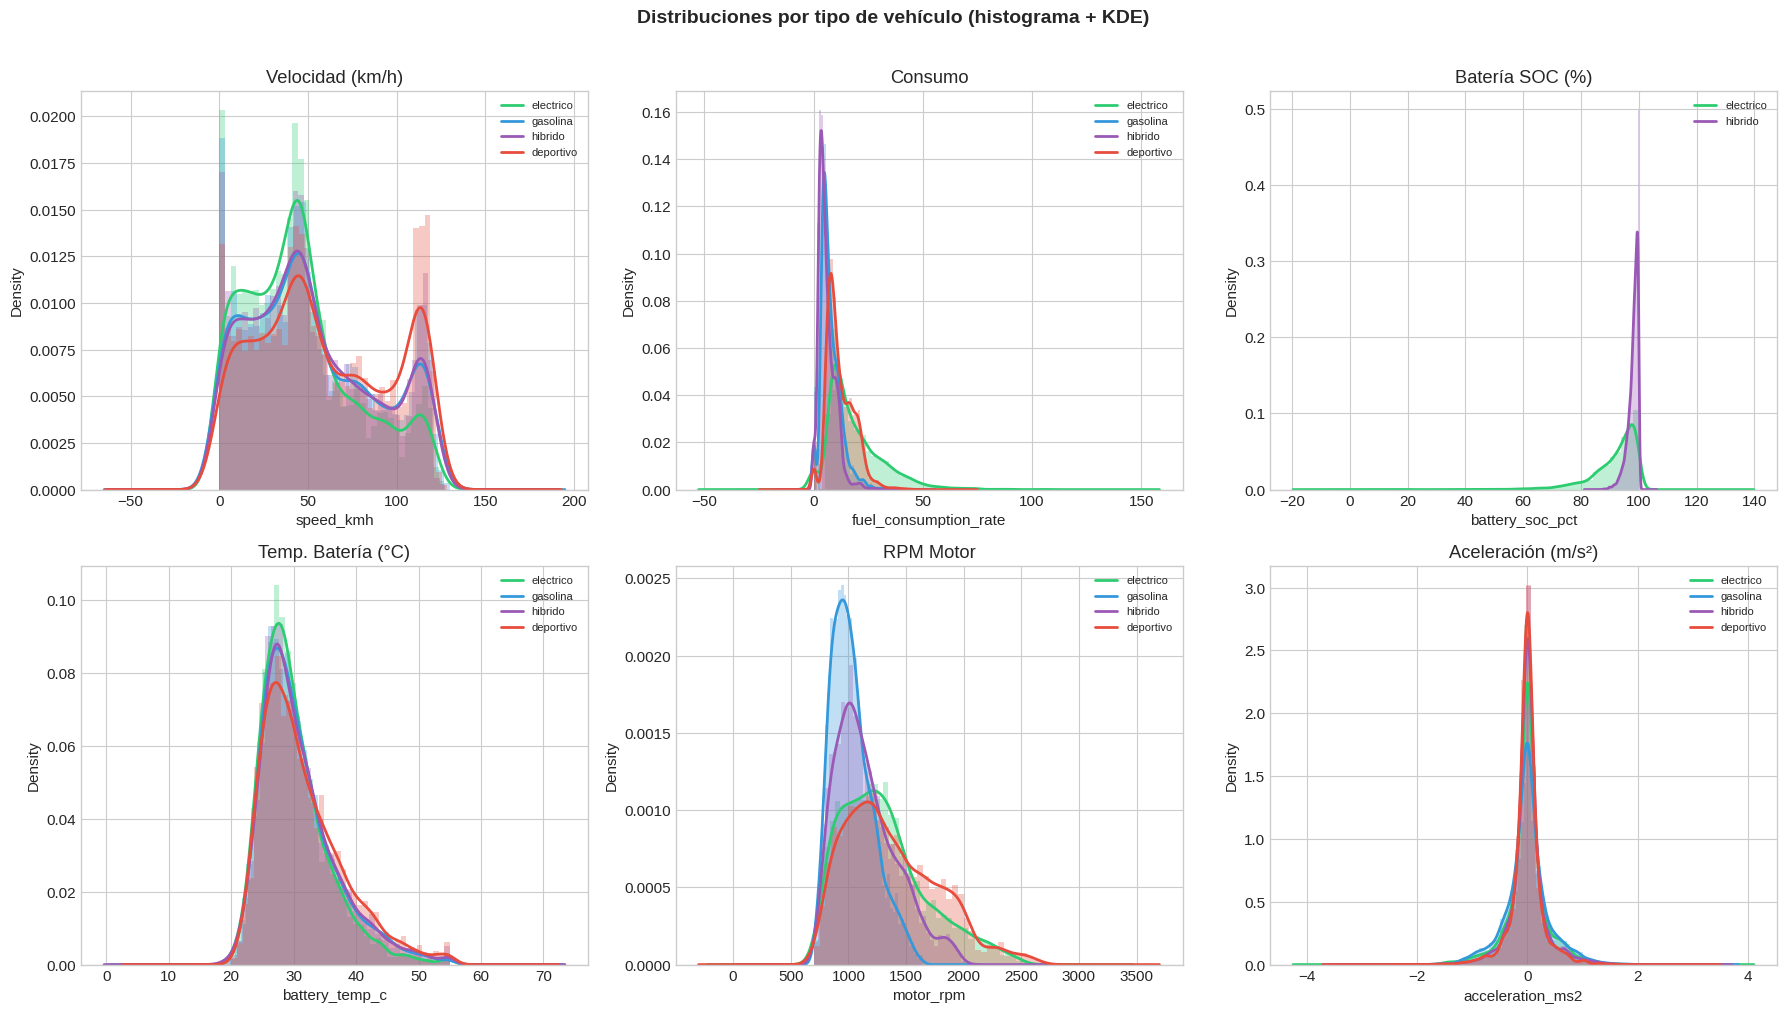

In [4]:
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, var, title in zip(axes.flat, 
    ['speed_kmh', 'fuel_consumption_rate', 'battery_soc_pct', 'battery_temp_c', 'motor_rpm', 'acceleration_ms2'],
    ['Velocidad (km/h)', 'Consumo', 'Batería SOC (%)', 'Temp. Batería (°C)', 'RPM Motor', 'Aceleración (m/s²)']):
    
    for vtype, color in vtype_colors.items():
        subset = telemetry[telemetry['vehicle_type'] == vtype][var].dropna()
        if len(subset) < 10:  # Saltar si no hay suficientes datos para este tipo
            continue
        # Submuestrear para rendimiento del KDE
        sample = subset.sample(min(5000, len(subset)), random_state=42)
        ax.hist(sample, bins=40, alpha=0.3, color=color, density=True)
        sample.plot.kde(ax=ax, color=color, linewidth=2, label=vtype)
    
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones por tipo de vehículo (histograma + KDE)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Box plots comparativos

/tmp/ipykernel_14928/250617224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=sample, x='vehicle_type', y=var, ax=ax, order=order,
/tmp/ipykernel_14928/250617224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=sample, x='vehicle_type', y=var, ax=ax, order=order,
/tmp/ipykernel_14928/250617224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=sample, x='vehicle_type', y=var, ax=ax, order=order,
/tmp/ipykernel_14928/250617224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

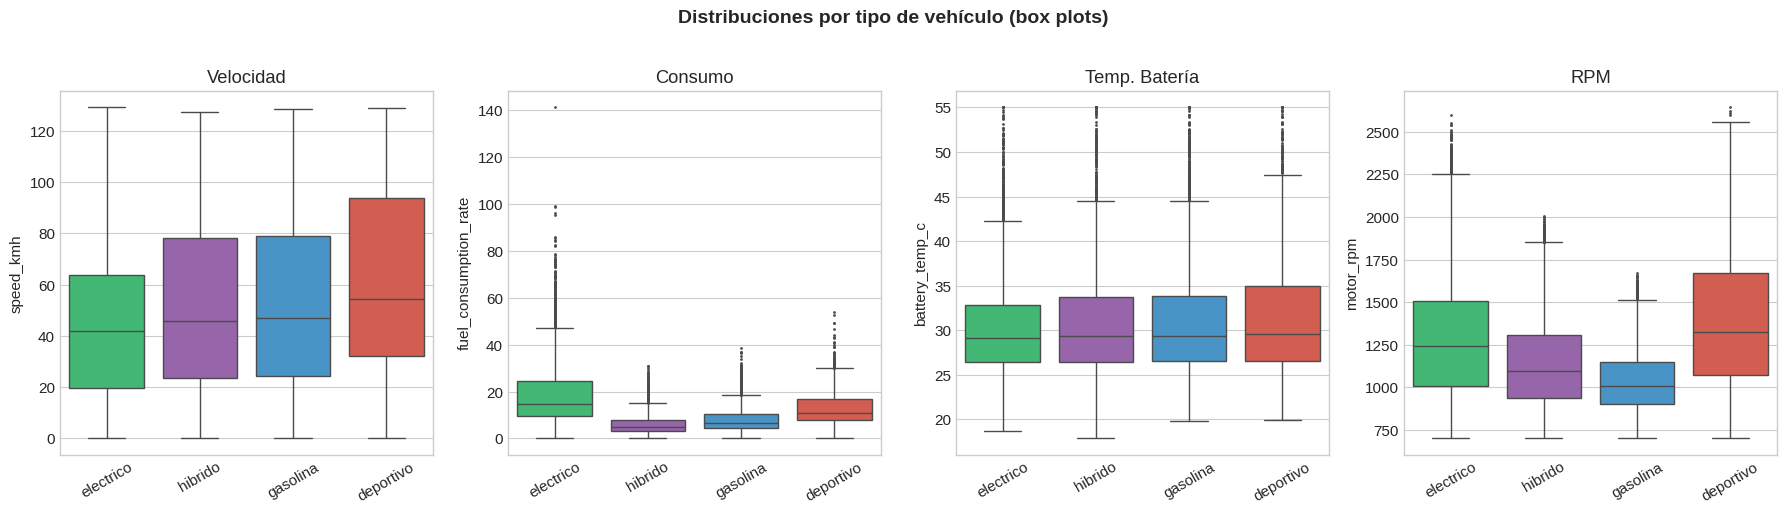

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, var, title in zip(axes, 
    ['speed_kmh', 'fuel_consumption_rate', 'battery_temp_c', 'motor_rpm'],
    ['Velocidad', 'Consumo', 'Temp. Batería', 'RPM']):
    
    # Submuestrear para rendimiento
    sample = telemetry[['vehicle_type', var]].dropna().sample(min(20000, len(telemetry)), random_state=42)
    
    order = ['electrico', 'hibrido', 'gasolina', 'deportivo']
    bp = sns.boxplot(data=sample, x='vehicle_type', y=var, ax=ax, order=order,
                     palette=vtype_colors, fliersize=1)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribuciones por tipo de vehículo (box plots)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Detección de outliers

Dos métodos comunes:
- **IQR**: robusto, no asume distribución normal
- **Z-score**: asume normalidad, sensible a outliers extremos

In [6]:
# Método IQR
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper), lower, upper

# Método Z-score
def detect_outliers_zscore(series, threshold=3):
    z = np.abs((series - series.mean()) / series.std())
    return z > threshold

# Aplicar a velocidad
speed = telemetry['speed_kmh'].dropna()
outliers_iqr, lower, upper = detect_outliers_iqr(speed)
outliers_z = detect_outliers_zscore(speed)

print(f"Velocidad - Outliers IQR: {outliers_iqr.sum():,} ({outliers_iqr.mean()*100:.2f}%)")
print(f"Velocidad - Outliers Z-score: {outliers_z.sum():,} ({outliers_z.mean()*100:.2f}%)")
print(f"Límites IQR: [{lower:.1f}, {upper:.1f}] km/h")

Velocidad - Outliers IQR: 0 (0.00%)
Velocidad - Outliers Z-score: 0 (0.00%)
Límites IQR: [-55.1, 153.8] km/h


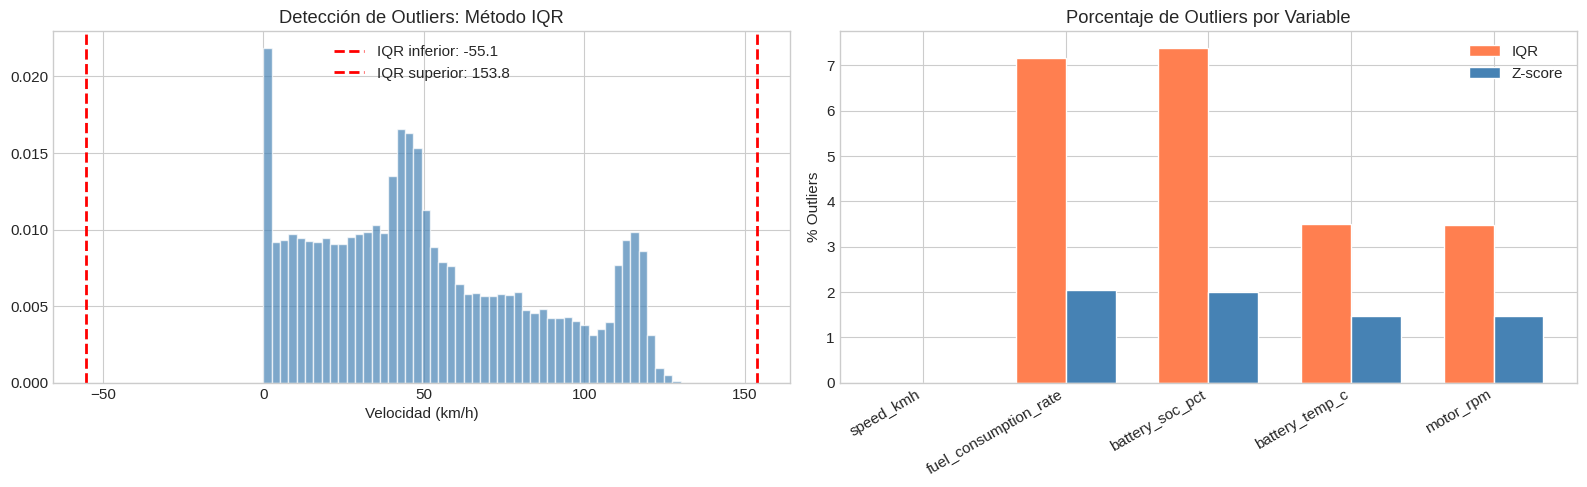

In [7]:
# Visualizar outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma con límites IQR
axes[0].hist(speed.sample(50000, random_state=42), bins=50, color='steelblue', edgecolor='white', alpha=0.7, density=True)
axes[0].axvline(lower, color='red', linestyle='--', linewidth=2, label=f'IQR inferior: {lower:.1f}')
axes[0].axvline(upper, color='red', linestyle='--', linewidth=2, label=f'IQR superior: {upper:.1f}')
axes[0].set_xlabel('Velocidad (km/h)')
axes[0].set_title('Detección de Outliers: Método IQR')
axes[0].legend()

# Resumen de outliers por variable
outlier_summary = []
for var in key_vars:
    s = telemetry[var].dropna()
    iqr_mask, _, _ = detect_outliers_iqr(s)
    z_mask = detect_outliers_zscore(s)
    outlier_summary.append({
        'variable': var,
        'outliers_iqr_pct': iqr_mask.mean() * 100,
        'outliers_zscore_pct': z_mask.mean() * 100,
    })

ols = pd.DataFrame(outlier_summary)
x = np.arange(len(ols))
width = 0.35
axes[1].bar(x - width/2, ols['outliers_iqr_pct'], width, label='IQR', color='coral', edgecolor='white')
axes[1].bar(x + width/2, ols['outliers_zscore_pct'], width, label='Z-score', color='steelblue', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ols['variable'], rotation=30, ha='right')
axes[1].set_ylabel('% Outliers')
axes[1].set_title('Porcentaje de Outliers por Variable')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Violin plots: distribución completa + box plot

/tmp/ipykernel_14928/2680425417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sample, x='vehicle_type', y='speed_kmh', ax=axes[0],
/tmp/ipykernel_14928/2680425417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sample, x='vehicle_type', y='fuel_consumption_rate', ax=axes[1],


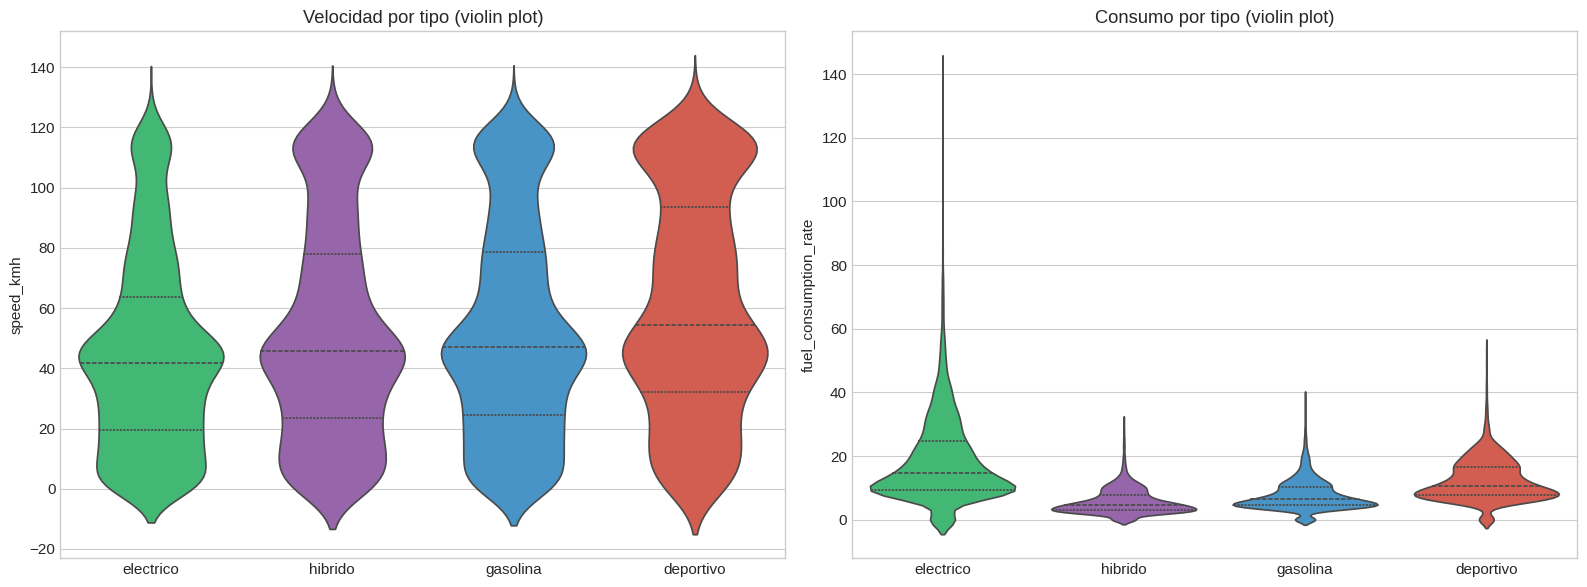

→ Los violin plots muestran la forma completa de la distribución + los cuartiles
→ Más informativos que un box plot cuando las distribuciones son multimodales


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = telemetry[['vehicle_type', 'speed_kmh', 'fuel_consumption_rate']].dropna().sample(20000, random_state=42)

sns.violinplot(data=sample, x='vehicle_type', y='speed_kmh', ax=axes[0],
               palette=vtype_colors, order=['electrico', 'hibrido', 'gasolina', 'deportivo'],
               inner='quartile')
axes[0].set_title('Velocidad por tipo (violin plot)')
axes[0].set_xlabel('')

sns.violinplot(data=sample, x='vehicle_type', y='fuel_consumption_rate', ax=axes[1],
               palette=vtype_colors, order=['electrico', 'hibrido', 'gasolina', 'deportivo'],
               inner='quartile')
axes[1].set_title('Consumo por tipo (violin plot)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("→ Los violin plots muestran la forma completa de la distribución + los cuartiles")
print("→ Más informativos que un box plot cuando las distribuciones son multimodales")

## Resumen

### Respuesta:
> **¿Cuál es el comportamiento típico de la flota?**
>
> Cada tipo de vehículo tiene un perfil distintivo. Los deportivos tienen mayor velocidad
> media y variabilidad, los eléctricos menor consumo en ciudad. Los outliers representan
> eventos de aceleración/frenado brusco y son más frecuentes en conductores agresivos.

### Siguiente notebook:
→ `02_temporal_patterns.ipynb`: Patrones temporales